### Imports and data loading
Load the feature engineering library, raw transactions, and user metadata needed to compute the full feature matrix.


In [16]:
import sys
sys.path.append('..')  # so we can import feature_engine
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from training.feature_engine import (
    compute_features,
    _features_magnitude,
    _features_velocity,
    _features_stability,
    _features_concentration,
    _features_behavioral,
    _features_identity,
    validate_features,
    compute_features_batch
)

# Load synthetic data
users = pd.read_parquet('../data/synth_users.parquet')
print("Read users.parquet")
txns = pd.read_parquet('../data/synth_transactions.parquet')
print("Read transactions.parquet")
labels = pd.read_parquet('../data/synth_labels.parquet')
print("Read labels.parquet")

# Ensure timestamps are real datetimes (Parquet preserves them, but double-check)
txns['occurred_at'] = pd.to_datetime(txns['occurred_at'])
users['onboarding_date'] = pd.to_datetime(users['onboarding_date'])

print(f"Users:        {len(users):,}")
print(f"Transactions: {len(txns):,}")
print(f"Labels:       {len(labels):,}")
print(f"Date range:   {txns['occurred_at'].min()} to {txns['occurred_at'].max()}")

Read users.parquet
Read transactions.parquet
Read labels.parquet
Users:        10,000
Transactions: 22,686,174
Labels:       10,000
Date range:   2025-11-01 06:03:59.272140 to 2026-04-29 22:56:09.722563


### Single-user smoke test
Run a focused smoke test for one representative user to verify that feature extraction works correctly on a known-good input.


In [17]:
# Section 2: Smoke test on one user
# Pick a user with rich transaction history so all features have data to work with
sample_user_id = users['user_id'].iloc[42]  # arbitrary
sample_meta = users[users['user_id'] == sample_user_id].iloc[0].to_dict()
sample_txns = txns[txns['user_id'] == sample_user_id].copy()

print(f"User: {sample_user_id}")
print(f"Archetype: {sample_meta['archetype']}")
print(f"Total transactions: {len(sample_txns):,}")
print(f"Date range: {sample_txns['occurred_at'].min()} to {sample_txns['occurred_at'].max()}")

# Pick as_of: last transaction day minus 1 (so as_of is strictly after some history)
as_of = sample_txns['occurred_at'].max()

# Run each family individually to localize any errors
print("\n=== Family 1: Magnitude ===")
m = _features_magnitude(sample_txns, as_of)
for k, v in sorted(m.items()):
    print(f"  {k:35s} = {v:,.2f}" if isinstance(v, float) else f"  {k:35s} = {v}")

print("\n=== Family 2: Velocity ===")
v = _features_velocity(sample_txns, as_of)
for k, val in sorted(v.items()):
    print(f"  {k:35s} = {val:,.2f}" if isinstance(val, float) else f"  {k:35s} = {val}")

print("\n=== Family 3: Stability ===")
s = _features_stability(sample_txns, as_of)
for k, val in sorted(s.items()):
    print(f"  {k:35s} = {val:,.4f}" if isinstance(val, float) else f"  {k:35s} = {val}")

print("\n=== Family 4: Concentration ===")
c = _features_concentration(sample_txns, as_of)
for k, val in sorted(c.items()):
    print(f"  {k:35s} = {val:,.4f}" if isinstance(val, float) else f"  {k:35s} = {val}")

print("\n=== Family 5: Behavioral ===")
b = _features_behavioral(sample_txns, as_of)
for k, val in sorted(b.items()):
    print(f"  {k:35s} = {val:,.4f}" if isinstance(val, float) else f"  {k:35s} = {val}")

print("\n=== Family 6: Identity ===")
i = _features_identity(sample_meta, as_of)
for k, val in sorted(i.items()):
    print(f"  {k:35s} = {val}")

User: 82c421c1-1624-46db-ae81-74d72e2bd704
Archetype: electronics_retailer
Total transactions: 872
Date range: 2025-11-01 10:01:07.253334 to 2026-04-29 19:12:20.606281

=== Family 1: Magnitude ===
  max_txn_amount_30d                  = 17,263,562.00
  mean_txn_amount_30d                 = 1,601,546.07
  median_txn_amount_30d               = 930,212.00
  std_txn_amount_30d                  = 2,202,572.80
  total_inflow_30d                    = 232,224,180.00
  total_inflow_7d                     = 46,949,863.00
  total_inflow_90d                    = 649,186,469.00
  total_outflow_30d                   = 0.00

=== Family 2: Velocity ===
  active_days_30d                     = 30.00
  activity_density_30d                = 1.00
  avg_gap_days_30d                    = 0.20
  days_since_last_txn                 = 0.00
  longest_dry_spell_30d               = 1.00
  txn_count_30d                       = 145.00
  txn_count_7d                        = 32.00
  txn_count_90d                     

### Sanity assertions
Assert that the single-user feature output satisfies basic invariants and expected ranges to catch implementation issues early.


In [18]:
# Section 3: Hard sanity assertions on the single-user output
# These should all pass for any realistic user. If any fail, there's a bug.

all_feats = {**m, **v, **s, **c, **b, **i}

# Concentration ordering
assert all_feats['top1_share_30d'] <= all_feats['top5_share_30d'] + 1e-9, \
    f"top1 ({all_feats['top1_share_30d']}) > top5 ({all_feats['top5_share_30d']})"
assert all_feats['top5_share_30d'] <= all_feats['top10_share_30d'] + 1e-9, \
    f"top5 > top10"
assert all_feats['top10_share_30d'] <= 1.0 + 1e-9, "top10 share > 1.0"
assert all_feats['hhi_senders_30d'] <= all_feats['top1_share_30d'] + 1e-9, "HHI > top1"

# Magnitude ordering
assert all_feats['total_inflow_7d'] <= all_feats['total_inflow_30d'] + 1e-9
assert all_feats['total_inflow_30d'] <= all_feats['total_inflow_90d'] + 1e-9

# Velocity ordering
assert all_feats['txn_count_7d'] <= all_feats['txn_count_30d']
assert all_feats['txn_count_30d'] <= all_feats['txn_count_90d']
assert 0 <= all_feats['activity_density_30d'] <= 1.0
assert 0 <= all_feats['longest_dry_spell_30d'] <= 30

# Behavioral bounds
assert 0 <= all_feats['business_hours_share_30d'] <= 1.0
assert 0 <= all_feats['round_amount_ratio_30d'] <= 1.0
# Hour entropy max is log2(24) ≈ 4.58
assert all_feats['hour_entropy_30d'] <= 4.6 or np.isnan(all_feats['hour_entropy_30d'])

# No infinity anywhere
for k, val in all_feats.items():
    if isinstance(val, float):
        assert not np.isinf(val), f"{k} is infinite"

print("✓ All single-user sanity assertions passed")

✓ All single-user sanity assertions passed


### Multi-user Assertion Loop
Run the same feature sanity checks across a sample of users to validate consistency and edge-case behavior.


In [19]:
# Section 4: Run sanity assertions across many users
sample_size = 50
sample_users = users.sample(sample_size, random_state=1)

failures = []
for _, user_row in sample_users.iterrows():
    user_id = user_row['user_id']
    user_meta = user_row.to_dict()
    user_txns = txns[txns['user_id'] == user_id].copy()
    user_as_of = user_txns['occurred_at'].max() if len(user_txns) > 0 else as_of
    
    try:
        feats = compute_features(user_txns, user_as_of, user_meta=user_meta)
        # Assertions
        if not np.isnan(feats.get('top1_share_30d', np.nan)):
            assert feats['top1_share_30d'] <= feats['top5_share_30d'] + 1e-9
            assert feats['top5_share_30d'] <= feats['top10_share_30d'] + 1e-9
        for k, val in feats.items():
            if isinstance(val, float):
                assert not np.isinf(val), f"{k} infinite"
    except Exception as e:
        failures.append((user_id, str(e)))

print(f"Tested {sample_size} users; {len(failures)} failures")
for uid, err in failures[:5]:
    print(f"  {uid}: {err}")

Tested 50 users; 0 failures


### Full population batch run
Compute the feature matrix for the full population to build the dataset used for training and analysis.


In [20]:
# Section 5: Compute features for all users

# Pick a single global as_of for training (Option A from our discussion)
GLOBAL_AS_OF = txns['occurred_at'].max()
print(f"as_of: {GLOBAL_AS_OF}")

features_df = compute_features_batch(users, txns, GLOBAL_AS_OF)

print(f"\nFeatures shape: {features_df.shape}")
print(f"Expected: ({len(users)}, ~50)")

as_of: 2026-04-29 22:56:09.722563
  0/10000...
  500/10000...
  1000/10000...
  1500/10000...
  2000/10000...
  2500/10000...
  3000/10000...
  3500/10000...
  4000/10000...
  4500/10000...
  5000/10000...
  5500/10000...
  6000/10000...
  6500/10000...
  7000/10000...
  7500/10000...
  8000/10000...
  8500/10000...
  9000/10000...
  9500/10000...

Features shape: (10000, 43)
Expected: (10000, ~50)


### Distribution Validation
Inspect the numeric feature distributions to ensure values are reasonable and there are no obvious data quality issues.


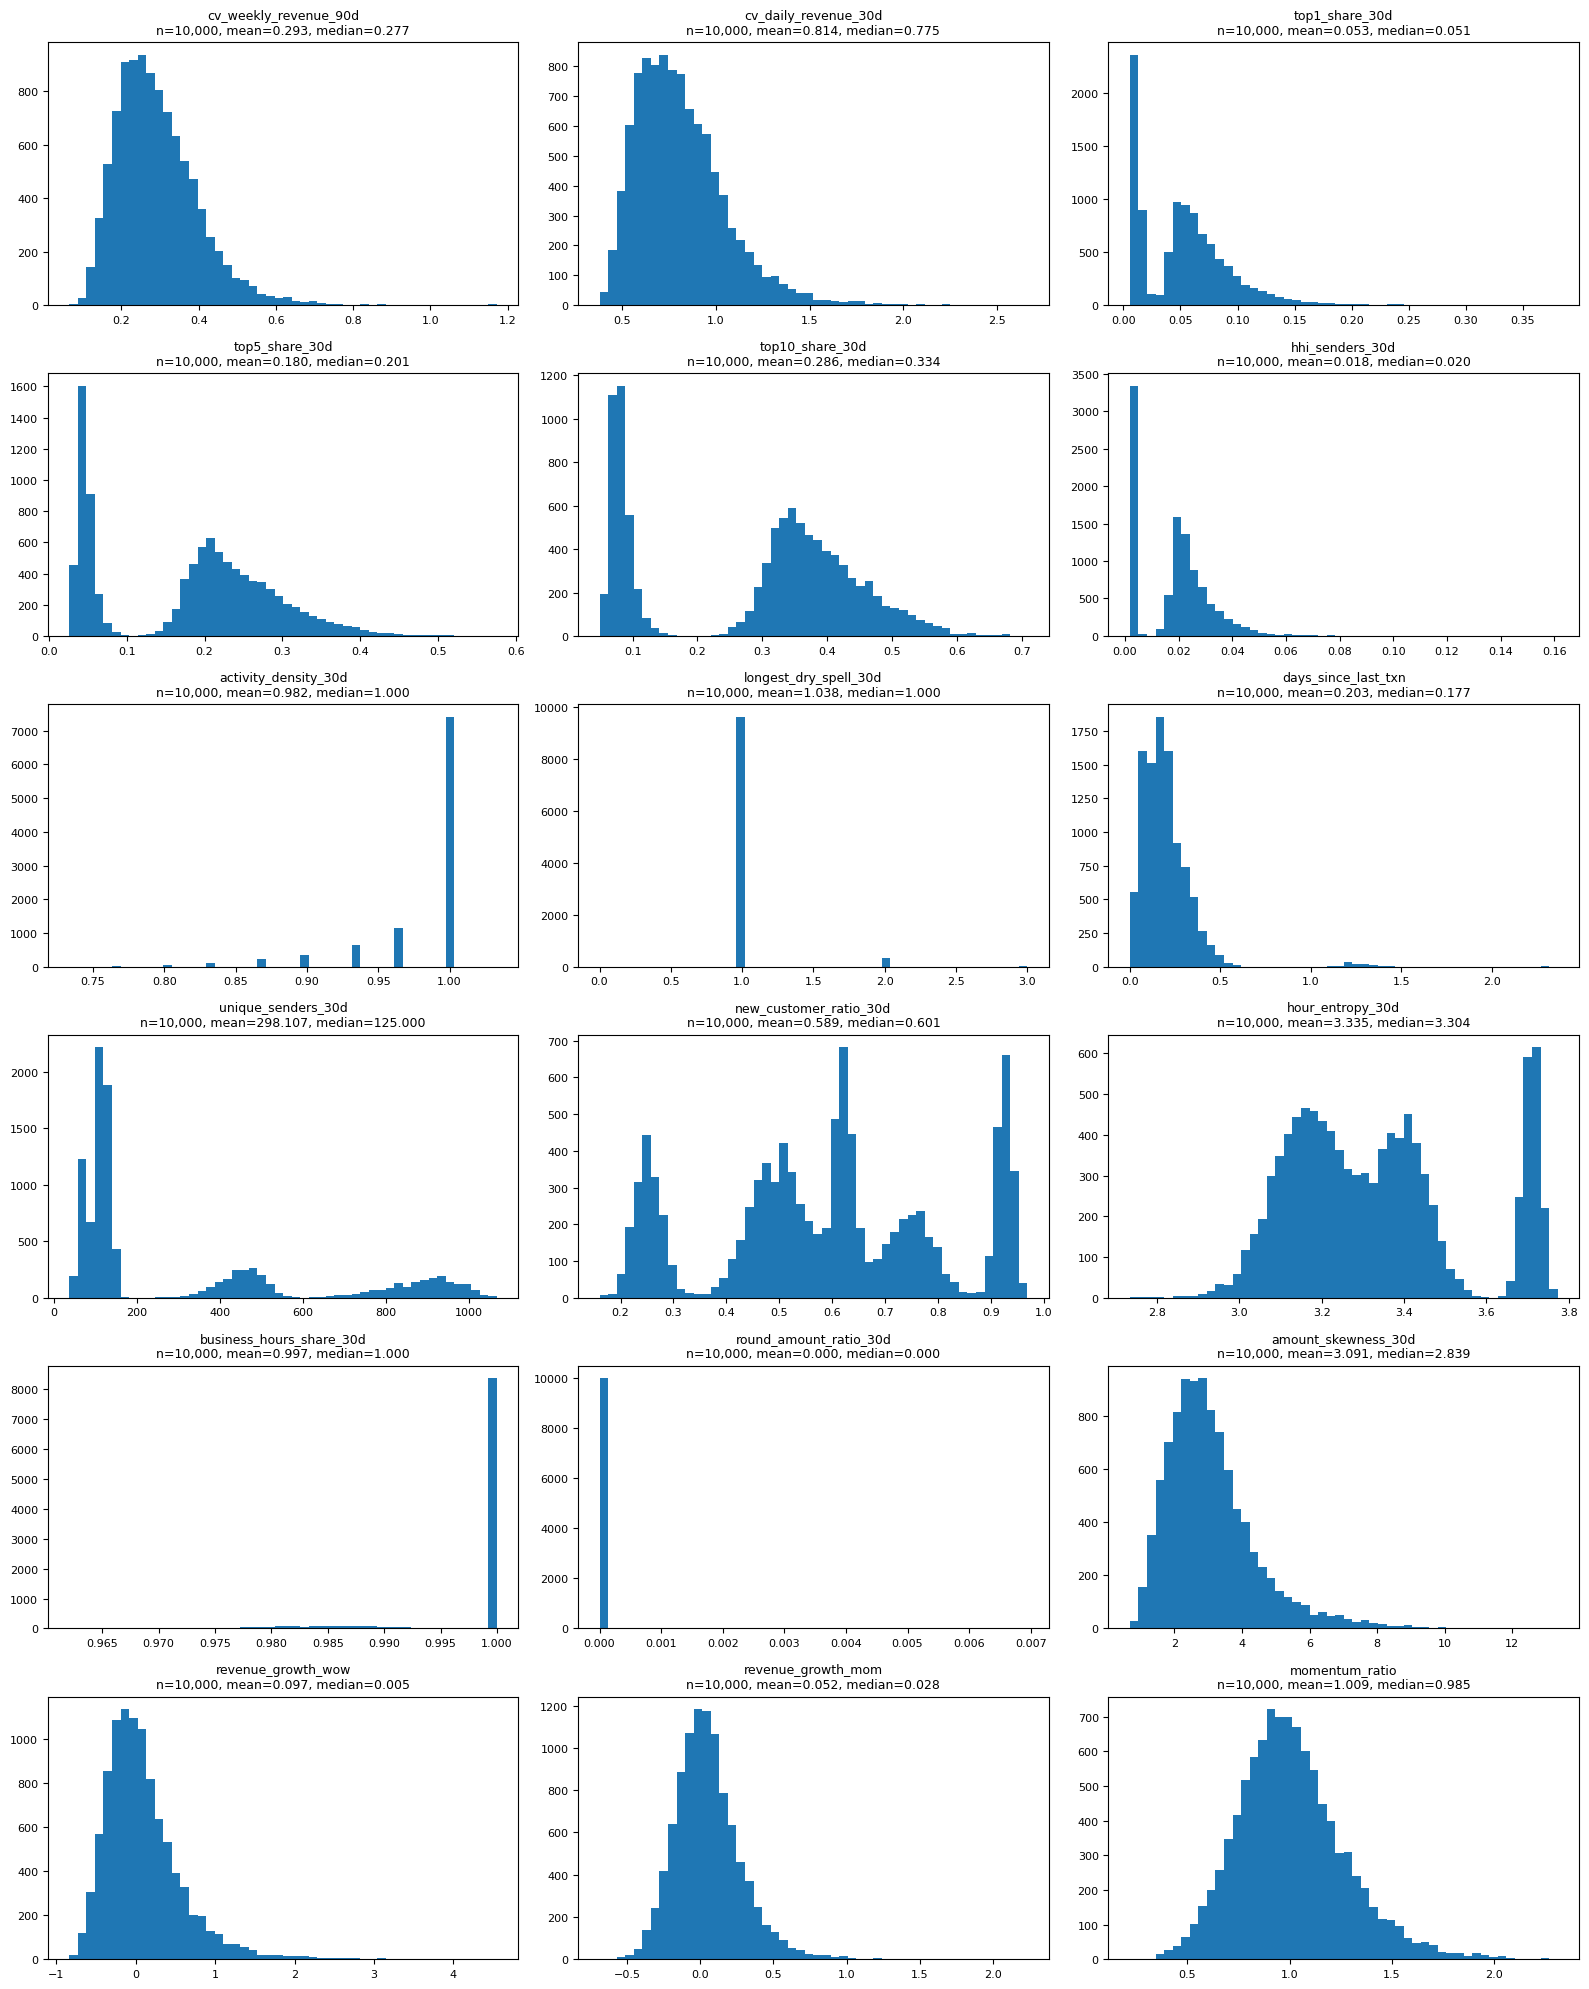

In [ ]:
# Distribution sanity plots
numeric_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('user_id') if 'user_id' in numeric_cols else None

# Group features visually for inspection
key_features = [
    'cv_weekly_revenue_90d', 'cv_daily_revenue_30d',
    'top1_share_30d', 'top5_share_30d', 'top10_share_30d', 'hhi_senders_30d',
    'activity_density_30d', 'longest_dry_spell_30d', 'days_since_last_txn',
    'unique_senders_30d', 'new_customer_ratio_30d',
    'hour_entropy_30d', 'business_hours_share_30d',
    'round_amount_ratio_30d', 'amount_skewness_30d',
    'revenue_growth_wow', 'revenue_growth_mom', 'momentum_ratio',
]

fig, axes = plt.subplots(6, 3, figsize=(16, 20))
for ax, feat in zip(axes.flat, key_features):
    if feat in features_df.columns:
        vals = features_df[feat].dropna()
        ax.hist(vals, bins=50)
        ax.set_title(f"{feat}\nn={len(vals):,}, mean={vals.mean():.3f}, "
                     f"median={vals.median():.3f}", fontsize=9)
        ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig('../data/feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

### Missingness audit
Measure the fraction of missing values in each feature to identify sparse signals and potential preprocessing needs.


In [ ]:
missingness = (features_df.isna().sum() / len(features_df)).sort_values(ascending=False)
print("Top missingness rates:")
print(missingness.head(15))
print("\nFeatures >50% missing (red flag):")
print(missingness[missingness > 0.5])

Top missingness rates:
total_inflow_7d            0.0
total_inflow_30d           0.0
total_inflow_90d           0.0
mean_txn_amount_30d        0.0
median_txn_amount_30d      0.0
std_txn_amount_30d         0.0
max_txn_amount_30d         0.0
total_outflow_30d          0.0
txn_count_7d               0.0
txn_count_30d              0.0
txn_count_90d              0.0
active_days_30d            0.0
activity_density_30d       0.0
txns_per_active_day_30d    0.0
avg_gap_days_30d           0.0
dtype: float64

Features >50% missing (red flag):
Series([], dtype: float64)


### Cross-archetype sanity
Compare feature summaries across archetypes to verify that engineered features behave sensibly for different business groups.


In [23]:
# Section 8: Do features vary sensibly across archetypes?
print("Mean of key features by archetype:")
display(features_df.groupby('archetype')[
    ['cv_weekly_revenue_90d', 'top1_share_30d', 'unique_senders_30d', 
     'activity_density_30d', 'mean_txn_amount_30d']
].mean().round(3))

Mean of key features by archetype:


,cv_weekly_revenue_90d,top1_share_30d,unique_senders_30d,activity_density_30d,mean_txn_amount_30d
archetype,,,,,
beauty_supplier,0.347,0.068,125.472,0.993,650844.460
electronics_retailer,0.382,0.083,117.913,0.980,1969000.929
market_food_vendor,0.269,0.053,112.256,0.999,252251.928
okada_rider,0.200,0.012,449.185,1.000,61672.383
pos_agent,0.233,0.013,888.004,1.000,108564.437
tailor_artisan,0.328,0.092,68.834,0.916,426017.367


### Save and prepare for training
Persist the final feature table to parquet so downstream notebooks can consume a stable, reusable dataset.


In [24]:
# Section 9: Save final feature table
features_df.to_parquet('../data/features_v1.parquet', index=False)
print(f"Saved features_df: {features_df.shape}")

# Build the training-ready table: features + labels
training_df = features_df.merge(labels[['user_id', 'default']], on='user_id', how='inner')
print(f"Training-ready shape: {training_df.shape}")
print(f"Default rate: {training_df['default'].mean():.1%}")

training_df.to_parquet('../data/training_v1.parquet', index=False)

Saved features_df: (10000, 43)
Training-ready shape: (10000, 44)
Default rate: 8.9%
